# Analyse de la performance commerciale (jeu de données Superstore)

**Objectif.** Identifier d'où vient le chiffre d'affaires, quels produits créent ou détruisent de la marge, et où concentrer les efforts commerciaux.

**Contexte.** Data analyst chez un distributeur de fournitures et de matériel de bureau. La direction dispose de quatre années de ventes (2009-2012) mais sans lecture synthétique : transformer un export brut en décisions.

**Données.** Jeu de données public *Superstore Sales* (8 399 lignes de commande), téléchargé par `src/telecharger_donnees.py`. Il fournit le profit réel par ligne, les remises, les sous-catégories et plusieurs régions.

**Compétences.** Python, pandas (préparation, groupby, pivot, séries temporelles), matplotlib/seaborn, KPI commerciaux, analyse de Pareto, analyse de rentabilité.


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.bbox"] = "tight"
FIG = os.path.join("..", "outputs", "figures")
os.makedirs(FIG, exist_ok=True)

## 1. Chargement et préparation

Le fichier est encodé en `latin-1` (présence d'accents). On sélectionne les
colonnes utiles et on les renomme en français pour la lisibilité de l'analyse.

In [2]:
brut = pd.read_csv(os.path.join("..", "data", "raw", "superstore_sales.csv"),
                   encoding="latin-1")
print("Dimensions brutes :", brut.shape)
brut.head(3)

Dimensions brutes : (8399, 21)


,Row ID,Order ID,Order Date,Order Priority,Order Quantity,Sales,Discount,Ship Mode,Profit,Unit Price,...,Customer Name,Province,Region,Customer Segment,Product Category,Product Sub-Category,Product Name,Product Container,Product Base Margin,Ship Date
0,1,3,10/13/2010,Low,6,261.54,0.04,Regular Air,-213.25,38.94,...,Muhammed MacIntyre,Nunavut,Nunavut,Small Business,Office Supplies,Storage & Organization,"Eldon Base for stackable storage shelf, platinum",Large Box,0.80,10/20/2010
1,49,293,10/1/2012,High,49,10123.02,0.07,Delivery Truck,457.81,208.16,...,Barry French,Nunavut,Nunavut,Consumer,Office Supplies,Appliances,"1.7 Cubic Foot Compact ""Cube"" Office Refrigera...",Jumbo Drum,0.58,10/2/2012
2,50,293,10/1/2012,High,27,244.57,0.01,Regular Air,46.71,8.69,...,Barry French,Nunavut,Nunavut,Consumer,Office Supplies,Binders and Binder Accessories,"Cardinal Slant-D¨ Ring Binder, Heavy Gauge Vinyl",Small Box,0.39,10/3/2012


In [3]:
colonnes = {
    "Order ID": "id_commande", "Order Date": "date_commande",
    "Product Name": "produit", "Product Category": "categorie",
    "Product Sub-Category": "sous_categorie", "Region": "region",
    "Province": "province", "Order Quantity": "quantite",
    "Sales": "chiffre_affaires", "Profit": "marge", "Discount": "remise",
    "Unit Price": "prix_unitaire", "Customer Segment": "segment_client",
    "Ship Mode": "mode_livraison",
}
df = brut[list(colonnes.keys())].rename(columns=colonnes).copy()
df["date_commande"] = pd.to_datetime(df["date_commande"], format="%m/%d/%Y")
print("Valeurs manquantes :", int(df.isna().sum().sum()))
print("Doublons de ligne  :", int(df.duplicated().sum()))

Valeurs manquantes : 0
Doublons de ligne  : 0


On crée les variables dérivées utiles à l'analyse.

In [4]:
df["taux_marge"] = df["marge"] / df["chiffre_affaires"]
df["mois"] = df["date_commande"].dt.to_period("M").dt.to_timestamp()
df["annee"] = df["date_commande"].dt.year
df["vente_a_perte"] = df["marge"] < 0
df[["chiffre_affaires", "marge", "taux_marge"]].describe().round(2)

,chiffre_affaires,marge,taux_marge
count,8399.00,8399.00,8399.00
mean,1775.88,181.18,-0.13
std,3585.05,1196.65,0.61
min,2.24,-14140.70,-11.44
25%,143.20,-83.32,-0.34
50%,449.42,-1.50,-0.01
75%,1709.32,162.75,0.22
max,89061.05,27220.69,0.98


## 2. KPI globaux

In [5]:
ca_total = df["chiffre_affaires"].sum()
marge_totale = df["marge"].sum()
nb_commandes = df["id_commande"].nunique()

print(f"Chiffre d'affaires total  : {ca_total:>13,.0f}")
print(f"Marge (profit) totale     : {marge_totale:>13,.0f}")
print(f"Taux de marge global      : {marge_totale/ca_total:>13.1%}")
print(f"Lignes de commande        : {len(df):>13,}")
print(f"Commandes distinctes      : {nb_commandes:>13,}")
print(f"Panier moyen / commande   : {ca_total/nb_commandes:>13,.0f}")
print(f"Part de lignes à perte    : {df['vente_a_perte'].mean():>13.1%}")
print(f"Période                   : {df['date_commande'].min().date()} -> {df['date_commande'].max().date()}")

Chiffre d'affaires total  :    14,915,601
Marge (profit) totale     :     1,521,768
Taux de marge global      :         10.2%
Lignes de commande        :         8,399
Commandes distinctes      :         5,496
Panier moyen / commande   :         2,714
Part de lignes à perte    :         50.8%
Période                   : 2009-01-01 -> 2012-12-30


Premier signal d'alerte : **plus de la moitié des lignes de commande
sont déficitaires** alors que l'entreprise reste globalement rentable. La marge
repose donc sur une minorité de transactions très rentables. On creuse.

## 3. Évolution temporelle du chiffre d'affaires

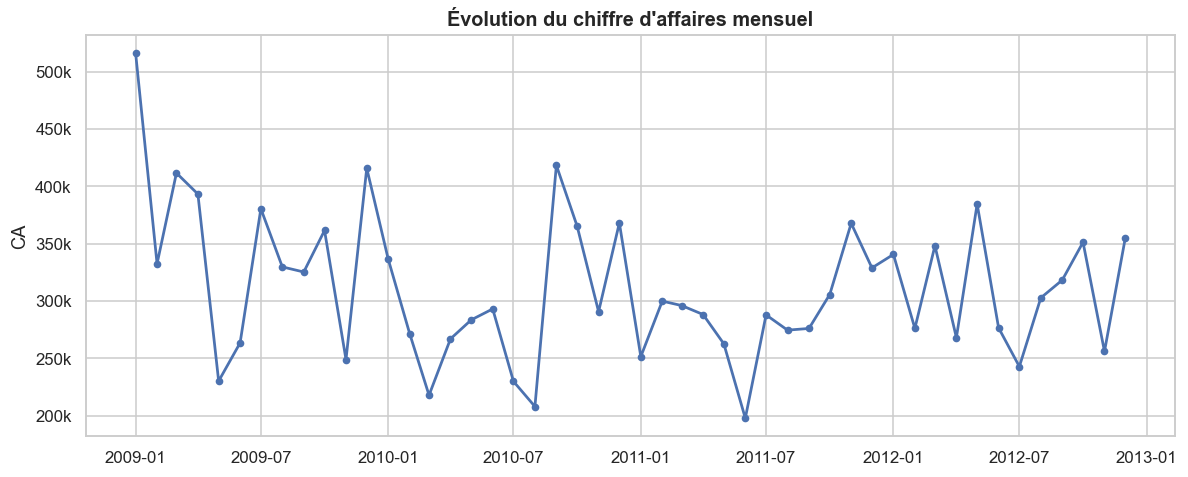

In [6]:
ca_mensuel = df.groupby("mois")["chiffre_affaires"].sum()
plt.figure(figsize=(11, 4.5))
plt.plot(ca_mensuel.index, ca_mensuel.values, marker="o", linewidth=1.8, markersize=4)
plt.title("Évolution du chiffre d'affaires mensuel", fontsize=13, fontweight="bold")
plt.ylabel("CA")
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1000:.0f}k"))
plt.tight_layout()
plt.savefig(os.path.join(FIG, "01_ca_mensuel.png"))
plt.show()

## 4. Concentration du CA : analyse de Pareto

Une poignée de sous-catégories fait-elle l'essentiel du chiffre d'affaires ?

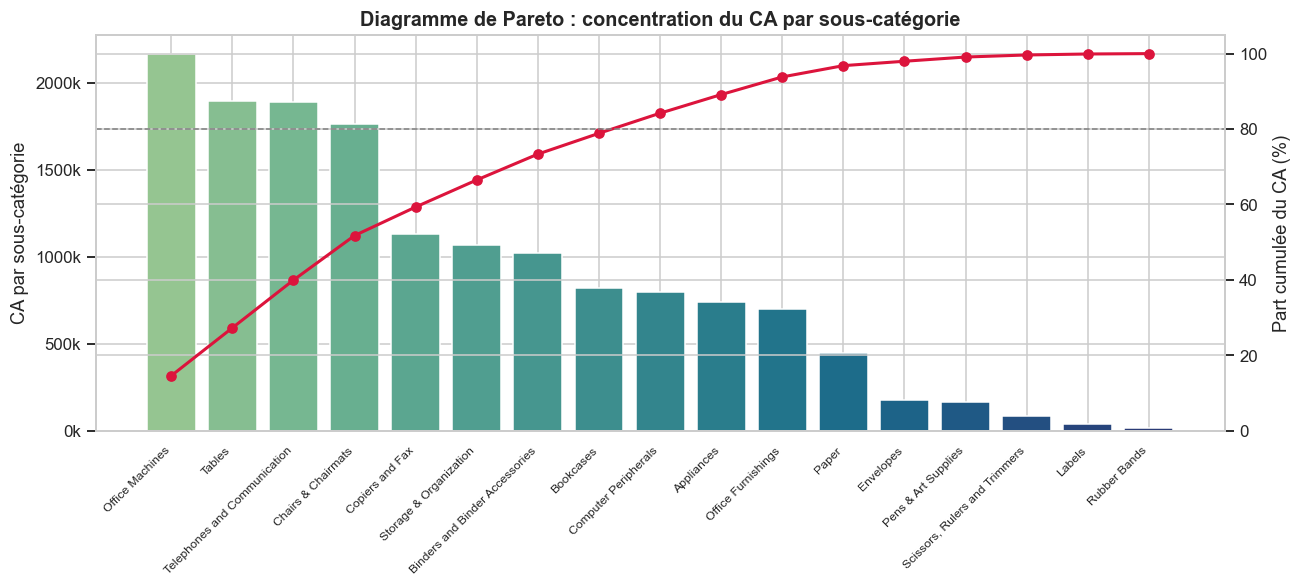

9 sous-catégories sur 17 réalisent 80 % du CA.


In [7]:
ca_sc = df.groupby("sous_categorie")["chiffre_affaires"].sum().sort_values(ascending=False)
ca_cum = ca_sc.cumsum() / ca_sc.sum()
n_80 = int((ca_cum <= 0.80).sum()) + 1

fig, ax1 = plt.subplots(figsize=(12, 5.5))
ax1.bar(range(len(ca_sc)), ca_sc.values, color=sns.color_palette("crest", len(ca_sc)))
ax1.set_ylabel("CA par sous-catégorie")
ax1.set_xticks(range(len(ca_sc)))
ax1.set_xticklabels(ca_sc.index, rotation=45, ha="right", fontsize=8)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1000:.0f}k"))
ax2 = ax1.twinx()
ax2.plot(range(len(ca_sc)), ca_cum.values * 100, color="crimson", marker="o", linewidth=2)
ax2.axhline(80, color="grey", linestyle="--", linewidth=1)
ax2.set_ylabel("Part cumulée du CA (%)"); ax2.set_ylim(0, 105)
plt.title("Diagramme de Pareto : concentration du CA par sous-catégorie",
          fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(FIG, "02_pareto.png"))
plt.show()
print(f"{n_80} sous-catégories sur {len(ca_sc)} réalisent 80 % du CA.")

## 5. Rentabilité par catégorie : volume contre marge

Le CA ne dit rien de la rentabilité. On croise CA, marge et part de lignes à
perte par catégorie.

In [8]:
synth_cat = df.groupby("categorie").agg(
    CA=("chiffre_affaires", "sum"),
    marge=("marge", "sum"),
    taux_marge_median=("taux_marge", "median"),
    part_lignes_perte=("vente_a_perte", "mean"),
    nb_lignes=("id_commande", "count"),
).sort_values("CA", ascending=False)
synth_cat.round(3)

,CA,marge,taux_marge_median,part_lignes_perte,nb_lignes
categorie,,,,,
Technology,5984248.182,886313.52,0.068,0.427,2065
Furniture,5178590.542,117433.03,-0.036,0.535,1724
Office Supplies,3752762.100,518021.43,-0.039,0.534,4610


La lecture est nette : **Technology** porte la marge, tandis que
**Furniture** génère un CA comparable mais une marge médiane négative. Le CA
élevé masque une faible création de valeur.

## 6. Performance géographique : région x catégorie

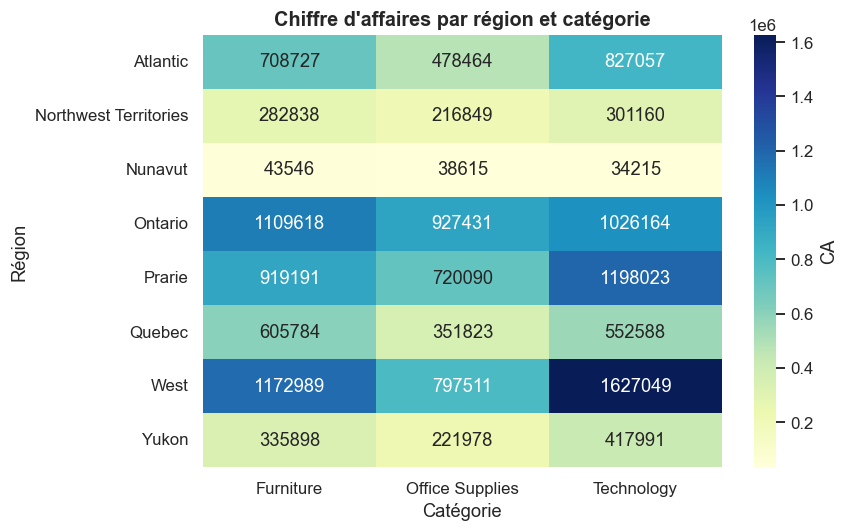

In [9]:
pivot = df.pivot_table(index="region", columns="categorie",
                       values="chiffre_affaires", aggfunc="sum")
plt.figure(figsize=(8, 5))
sns.heatmap(pivot, annot=True, fmt=".0f", cmap="YlGnBu", cbar_kws={"label": "CA"})
plt.title("Chiffre d'affaires par région et catégorie", fontsize=13, fontweight="bold")
plt.ylabel("Région"); plt.xlabel("Catégorie")
plt.tight_layout()
plt.savefig(os.path.join(FIG, "03_heatmap_region_categorie.png"))
plt.show()

## 7. Créateurs et destructeurs de valeur

L'analyse la plus parlante : quelles sous-catégories rapportent réellement, et
lesquelles **détruisent de la valeur** (marge totale négative) ?

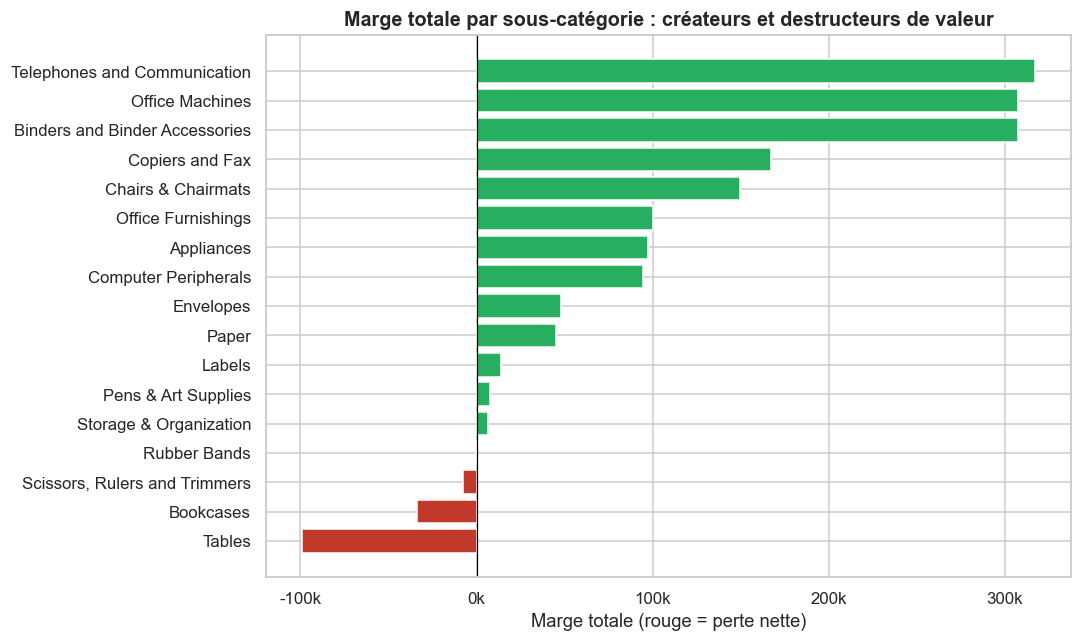

Sous-catégories à marge négative :
sous_categorie
Tables                          -99062.0
Bookcases                       -33582.0
Scissors, Rulers and Trimmers    -7799.0
Rubber Bands                      -103.0
Name: marge, dtype: float64


In [10]:
marge_sc = df.groupby("sous_categorie")["marge"].sum().sort_values()
couleurs = ["#c0392b" if v < 0 else "#27ae60" for v in marge_sc.values]
plt.figure(figsize=(10, 6))
plt.barh(marge_sc.index, marge_sc.values, color=couleurs)
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Marge totale par sous-catégorie : créateurs et destructeurs de valeur",
          fontsize=13, fontweight="bold")
plt.xlabel("Marge totale (rouge = perte nette)")
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1000:.0f}k"))
plt.tight_layout()
plt.savefig(os.path.join(FIG, "04_marge_sous_categorie.png"))
plt.show()
print("Sous-catégories à marge négative :")
print(marge_sc[marge_sc < 0].round(0))

## 8. Performance par segment client

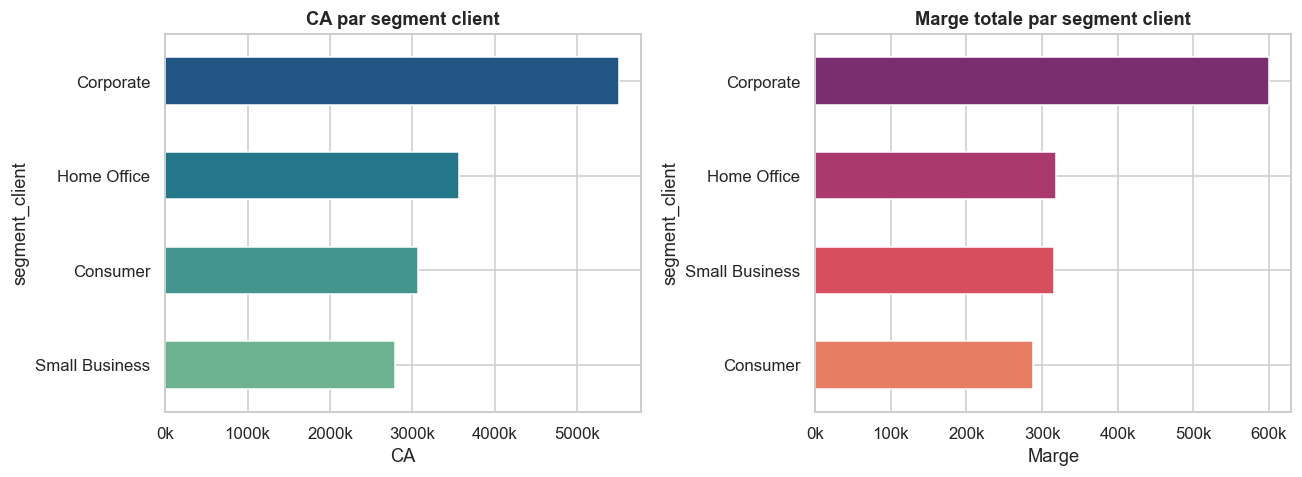

,ca,marge,panier_moyen
segment_client,,,
Corporate,5498905.0,599746.0,1788.0
Home Office,3564764.0,318354.0,1754.0
Consumer,3063611.0,287960.0,1858.0
Small Business,2788321.0,315708.0,1698.0


In [11]:
synth_seg = df.groupby("segment_client").agg(
    ca=("chiffre_affaires", "sum"), marge=("marge", "sum"),
    panier_moyen=("chiffre_affaires", "mean")).sort_values("ca", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
synth_seg["ca"].sort_values().plot(kind="barh", ax=axes[0], color=sns.color_palette("crest", 4))
axes[0].set_title("CA par segment client", fontweight="bold"); axes[0].set_xlabel("CA")
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1000:.0f}k"))
synth_seg["marge"].sort_values().plot(kind="barh", ax=axes[1], color=sns.color_palette("flare", 4))
axes[1].set_title("Marge totale par segment client", fontweight="bold"); axes[1].set_xlabel("Marge")
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1000:.0f}k"))
plt.tight_layout()
plt.savefig(os.path.join(FIG, "05_segment.png"))
plt.show()
display(synth_seg.round(0))

## 9. Export des données enrichies

In [12]:
df.to_csv(os.path.join("..", "data", "processed", "ventes_enrichies.csv"),
          index=False, encoding="utf-8")
print("Données enrichies exportées.")

Données enrichies exportées.


## 10. Conclusions métier

**La rentabilité repose sur peu de transactions.** Plus de la moitié des lignes
de commande sont déficitaires, mais l'entreprise reste bénéficiaire grâce à une
minorité de ventes très rentables. Le pilotage par le seul chiffre d'affaires
serait trompeur.

**Technology est le moteur de marge.** À CA comparable, la catégorie Technology
dégage une marge très supérieure à Furniture, dont la marge médiane est
négative : un CA élevé n'y crée presque pas de valeur.

**Certaines sous-catégories détruisent de la valeur.** Les Tables affichent la
marge totale la plus négative, suivies des Bookcases. Ces lignes méritent une
révision tarifaire ou un arbitrage d'assortiment.

**Le segment Corporate est le plus contributeur**, en CA comme en marge, ce qui
justifie un suivi commercial dédié.

**Recommandations.**
- Renégocier les conditions ou revoir l'assortiment des sous-catégories
  déficitaires (Tables, Bookcases en priorité).
- Suivre la marge, pas seulement le CA, dans le reporting commercial.
- Renforcer la relation avec le segment Corporate.
